In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.utils import resample
from scipy.stats import norm
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd

A:OLS for the Runge function
-

Write your own code (using for example the pseudoinverse function pinv from numpy, or
the SVD directly) and perform a standard ordinary least squares regression analysis using
polynomials in x up to order 15 or higher.

In [2]:
def runge(x):
    return (1.0/(1.0+25*x**2))

def design_matrix(x, degree):
    X = np.vander(x, degree +1 , increasing=True)
    return X

rng = np.random.default_rng(2026)
n = 100
sigma = 0.1
x = np.sort(rng.uniform(-1,1,n))
y = runge(x) + rng.normal(0, sigma,n)


def exercisedata(x, y, d, sigma = 0.1, n=100):
    rng = np.random.default_rng(2026)
    n = n
    sigma = sigma
    x = np.sort(rng.uniform(-1,1,n))
    y = runge(x) + rng.normal(0, sigma,n)
    

    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=2026)
    scaler = StandardScaler()
    Xtr = design_matrix(x_train, d)
    Xtr_sc = np.copy(Xtr)
    Xtr_sc[:,1:] = scaler.fit_transform(Xtr[:,1:]) 
    Xte = design_matrix(x_test, d)
    Xte_sc = np.copy(Xte)
    Xte_sc[:,1:] = scaler.transform(Xte[:,1:]) 
    theta = np.linalg.lstsq(Xtr_sc, y_train, rcond=None)[0]

    return theta, Xtr_sc, Xte_sc, y_train, y_test
    
degrees = np.arange(1,16)

mse_train, mse_test = [], []
R2_train, R2_test = [], []
theta_values = []

for d in degrees:
    theta, Xtr_sc, Xte_sc, y_train, y_test = exercisedata(x, y, d,sigma, n)
    theta_values.append(theta)
    y_train_pred = Xtr_sc @ theta
    y_test_pred = Xte_sc @ theta
    mse_train.append(mean_squared_error(y_train, y_train_pred))
    mse_test.append(mean_squared_error(y_test, y_test_pred))
    R2_train.append(r2_score(y_train, y_train_pred))
    R2_test.append(r2_score(y_test, y_test_pred))

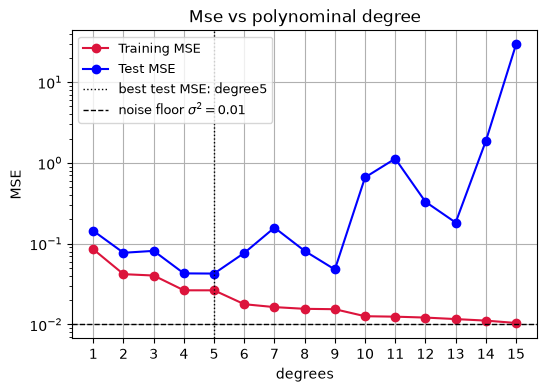

In [3]:
best_degree = degrees[int(np.argmin(mse_test))]
plt.figure(figsize=(6,4))
plt.plot(degrees, mse_train, "o-", color = "crimson", label = "Training MSE")
plt.plot(degrees, mse_test, "o-", color = "blue", label = "Test MSE")
plt.axvline(best_degree, color = "k", ls = ":", lw=1, label=f"best test MSE: degree{best_degree}")
plt.axhline(0.1**2, color = "k", ls = "--", lw=1, label=f"noise floor $\sigma ^2 = 0.01$")
plt.xlabel("degrees"); plt.ylabel("MSE"); plt.xticks(degrees); plt.legend(fontsize=9), plt.grid(True)
plt.title("Mse vs polynominal degree"); plt.yscale("log")


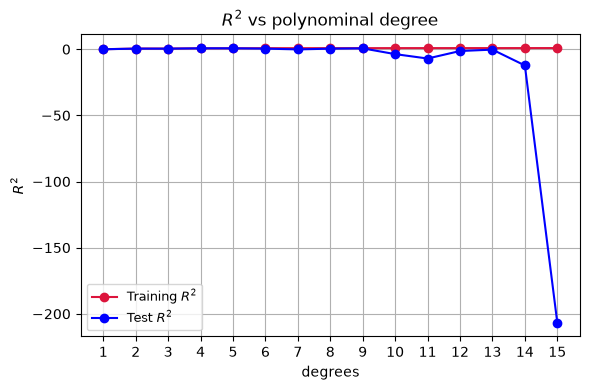

In [4]:
plt.figure(figsize=(6,4)); plt.plot(degrees, R2_train, "o-", color = "crimson", label = "Training $R^2$")
plt.plot(degrees, R2_test, "o-", color = "blue", label = "Test $R^2$")
plt.xlabel("degrees"); plt.ylabel("$R^2$"); plt.xticks(degrees); plt.legend(fontsize=9),
plt.grid(True); plt.title("$R^2$ vs polynominal degree"); plt.tight_layout();plt.show()

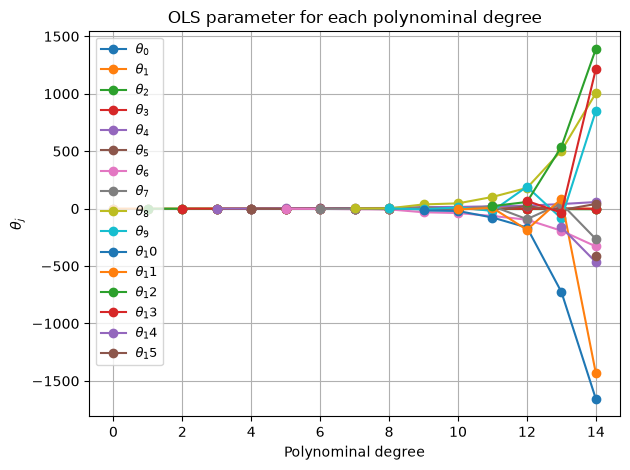

In [5]:
max_degrees = max(degrees)

for j in range(max_degrees + 1):
    theta_j = [theta[j] if j < len(theta) else np.nan for theta in theta_values]

    plt.plot(np.arange(len(theta_values)), theta_j, "o-", label = rf"$\theta_{j}$")

plt.xlabel(r"Polynominal degree"); plt.ylabel(r"$\theta_j$"); plt.title(r"OLS parameter for each polynominal degree")
plt.legend(fontsize=9); plt.tight_layout();plt.grid(True); plt.show()

B: Adding Ridge regression for the Runge function
-

In [15]:
theta, Xtr_sc, Xte_sc, yr_train, yr_test = exercisedata(x, y, d, sigma= 0.1, n=100)
I = np.eye(Xtr_sc.shape[1])
I[0,0] = 0
mse_r_train, mse_r_test = [], []
R2_r_train, R2_r_test = [], []
theta_r_values = []
lambdas = np.logspace(-5, 2, 61)
for l in lambdas:

    theta_r = np.linalg.solve(Xtr_sc.T @ Xtr_sc + l*I, Xtr_sc.T@yr_train)
    theta_r_values.append(theta_r)

    yr_train_pred = Xtr_sc@ theta_r
    yr_test_pred = Xte_sc @ theta_r

    mse_r_train.append(mean_squared_error(yr_train, yr_train_pred))
    mse_r_test.append(mean_squared_error(yr_test, yr_test_pred))

    R2_r_train.append(r2_score(yr_train, yr_train_pred))
    R2_r_test.append(r2_score(yr_test, yr_test_pred))

theta_r_values = np.array(theta_r_values)

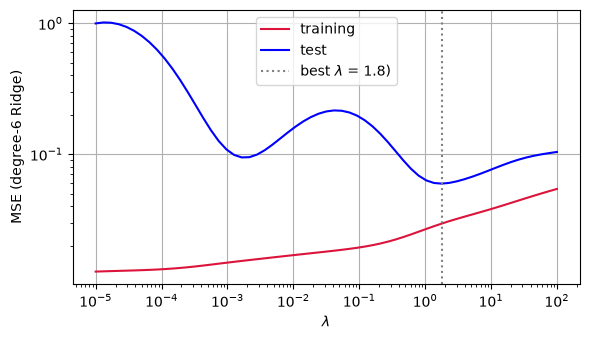

In [16]:
best = int(np.argmin(mse_r_test))
plt.figure(figsize=(6, 3.5))
plt.plot(lambdas, mse_r_train, ms=3, color = "crimson", label="training")
plt.plot(lambdas, mse_r_test, ms=3, color = "b", label="test")
plt.axvline(lambdas[best], color="gray", ls=":", label=rf"best $\lambda$ = {lambdas[best]:.2g})") ;plt.xscale("log"); plt.yscale("log")
plt.xlabel(r"$\lambda$"); plt.ylabel("MSE (degree-6 Ridge)"); plt.grid(True); plt.legend()
plt.tight_layout(); plt.show()

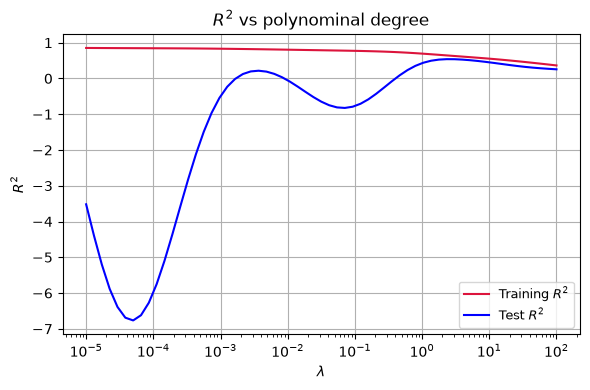

In [8]:
plt.figure(figsize=(6,4))
plt.semilogx(lambdas, R2_r_train, color = "crimson", label = "Training $R^2$")
plt.semilogx(lambdas, R2_r_test, color = "blue", label = "Test $R^2$")
plt.xlabel(fr"$\lambda$"); plt.ylabel("$R^2$"); plt.legend(fontsize=9),
plt.grid(True); plt.title("$R^2$ vs polynominal degree"); plt.tight_layout();plt.show()

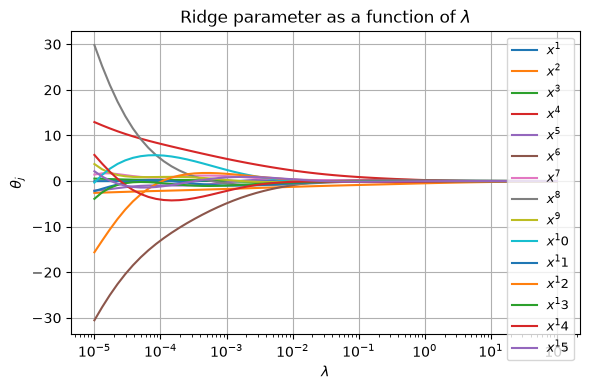

In [9]:
plt.figure(figsize=(6,4))
for j in range(1, theta_r_values.shape[1]):
    plt.semilogx(lambdas, theta_r_values[:, j], label = rf"$x^{j}$")

plt.xlabel(r"$\lambda$"); plt.ylabel(r"$\theta_j$"); plt.title(r"Ridge parameter as a function of $\lambda$")
plt.legend(fontsize=9); plt.tight_layout();plt.grid(True); plt.show()

C: The bias-variance tradeoff and the bootstrap method
-

In [ ]:
def runge_data(degree, n=100, sigma = 0.1, seed = 2026):
    
    mse_tr_c, mse_te_c, theta_values = [], [], []

    for d in degree:
        theta, Xtr_sc, Xte_sc, y_train, y_test =  exercisedata(x, y, d,sigma, n)
    
        theta_values.append(theta)

        y_train_pred = Xtr_sc @ theta
        y_test_pred = Xte_sc @ theta

        mse_tr_c.append(mean_squared_error(y_train, y_train_pred))
        mse_te_c.append(mean_squared_error(y_test, y_test_pred))
        

    return np.array(mse_tr_c), np.array(mse_te_c), theta_values

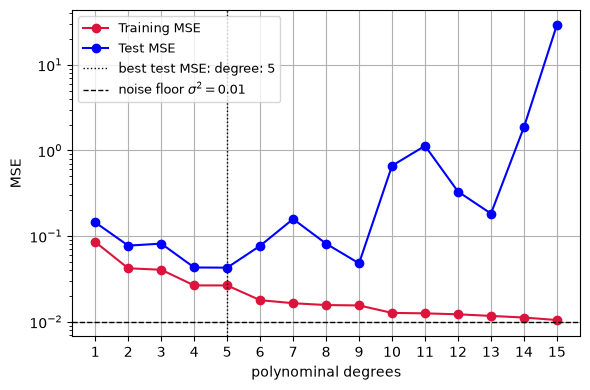

In [11]:
degrees = np.arange(1,16)
mse_tr, mse_te , theta_c = runge_data(degree=degrees, n=100, sigma = 0.1, seed = 2026)
best_degree = degrees[int(np.argmin(mse_te))]
plt.figure(figsize=(6,4))
plt.plot(degrees, mse_tr, "o-", color = "crimson", label = "Training MSE")
plt.plot(degrees, mse_te, "o-", color = "blue", label = "Test MSE")
plt.axvline(best_degree, color = "k", ls = ":", lw=1, label=f"best test MSE: degree: {best_degree}")
plt.axhline(0.1**2, color = "k", ls = "--", lw=1, label=f"noise floor $\sigma ^2 = 0.01$")
plt.xlabel("polynominal degrees"); plt.ylabel("MSE"); plt.xticks(degrees); plt.legend(fontsize=9), plt.grid(True)
plt.yscale("log"); plt.tight_layout(); plt.show()

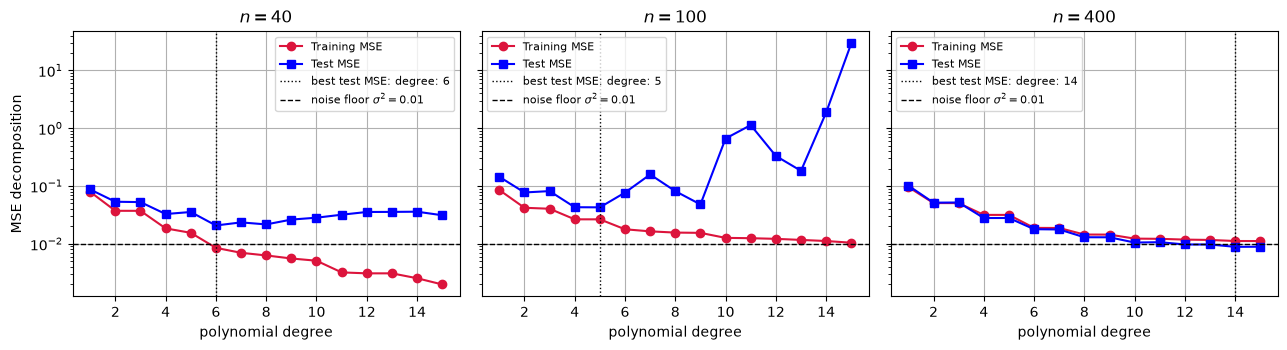

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), sharey=True)
for ax, n_ in zip(axes, (40, 100, 400)):
    mse_tr, mse_te, _ = runge_data(degree=degrees, n=n_, sigma = 0.1, seed = 2026)
    best_degree = degrees[int(np.argmin(mse_te))]
    ax.plot(degrees, mse_tr,"o-", color = "crimson", label = "Training MSE")
    ax.plot(degrees, mse_te,"s-", color = "b", label = f"Test MSE")
    ax.axvline(best_degree, color = "k", ls = ":", lw=1, label=f"best test MSE: degree: {best_degree}")
    ax.axhline(0.1**2, color = "k", ls = "--", lw=1, label=f"noise floor $\sigma ^2 = 0.01$")
    ax.set_yscale("log")
    ax.set_title(f"$n = {n_}$")
    ax.set_xlabel("polynomial degree")
    ax.grid(True)
    ax.legend(fontsize= 8)

axes[0].set_ylabel("MSE decomposition")

plt.tight_layout()
plt.show()

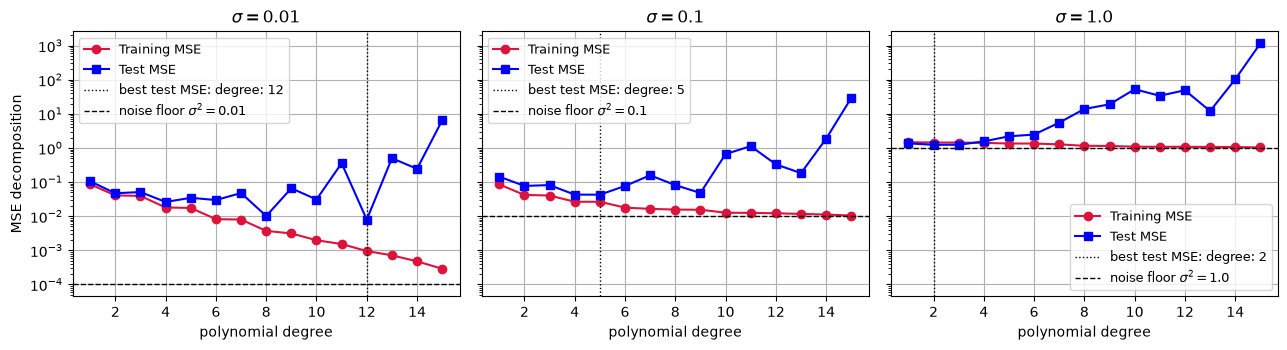

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), sharey=True)
for ax, s_ in zip(axes, (0.01, 0.1, 1.0)):
    mse_tr, mse_te, _ = runge_data(degree=degrees, n=100, sigma = s_, seed = 2026)
    best_degree = degrees[int(np.argmin(mse_te))]
    ax.plot(degrees, mse_tr,"o-", color = "crimson", label = "Training MSE")
    ax.plot(degrees, mse_te,"s-", color = "b", label = f"Test MSE")
    ax.axvline(best_degree, color = "k", ls = ":", lw=1, label=f"best test MSE: degree: {best_degree}")
    ax.axhline(s_**2, color = "k", ls = "--", lw=1, label=f"noise floor $\sigma ^2 = {s_}$")
    ax.set_yscale("log")
    ax.set_title(f"$\sigma = {s_}$")
    ax.set_xlabel("polynomial degree")
    ax.legend(fontsize= 9)
    ax.grid(True)

axes[0].set_ylabel("MSE decomposition")
plt.legend(fontsize= 9); plt.grid(True)
plt.tight_layout()
plt.show()

Bias-variance analasys of the runge function using the boot-starp method
-

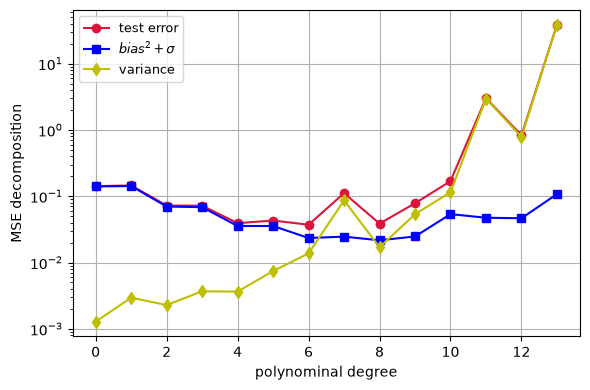

In [18]:
np.random.seed(2026)

n, n_bootstrap, maxdegree = 100, 100, 14
rng = np.random.default_rng(2026)
sigma = 0.1
x = np.sort(rng.uniform(-1,1,n))
x = np.asarray(x).reshape(-1, 1)
y = runge(x) + rng.normal(0, sigma, size = (n, 1))
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=2026)


error = np.zeros(maxdegree)
bias = np.zeros(maxdegree)
variance = np.zeros(maxdegree)

for degree in range(maxdegree):
    
    model = make_pipeline(PolynomialFeatures(degree=degree), LinearRegression(fit_intercept=False))
    y_pred = np.empty((y_test.shape[0], n_bootstrap))
    for i in range(n_bootstrap):
        x_, y_ = resample(x_train, y_train)
        y_pred[:,i] = model.fit(x_, y_).predict(x_test).ravel()

    error[degree] = np.mean(np.mean((y_test - y_pred)**2, axis=1, keepdims=True))
    bias[degree] = np.mean((y_test - np.mean(y_pred, axis=1, keepdims=True))**2)
    variance[degree] = np.mean(np.var(y_pred, axis=1, keepdims=True))

plt.subplots(figsize=(6,4))
plt.plot(range(maxdegree), error, "o-", color = "crimson", label = "test error")
plt.plot(range(maxdegree), bias, "s-", color = "b", label = r"$bias^2 + \sigma$")
plt.plot(range(maxdegree), variance, "d-", color = "y", label = "variance")
plt.xlabel("polynominal degree"); plt.ylabel("MSE decomposition")
plt.yscale("log"); plt.legend(fontsize=9); plt.grid(True)
plt.tight_layout(); plt.show()



In [22]:

deg = (0, 4, 8, 11,  maxdegree - 1)
table = pd.DataFrame({"Grad": deg, "Error": [error[d] for d in deg], "Bias": [bias[d] for d in deg], "variance": [variance[d] for d in deg], "sum": [bias[d] + variance[d] for d in deg] })
display(table.style.format(precision=4).hide(axis="index"))

Grad,Error,Bias,variance,sum
0,0.1418,0.1405,0.0013,0.1418
4,0.0392,0.0356,0.0036,0.0392
8,0.0386,0.0216,0.0170,0.0386
11,3.0110,0.0473,2.9636,3.0110
13,38.4291,0.1076,38.3215,38.4291


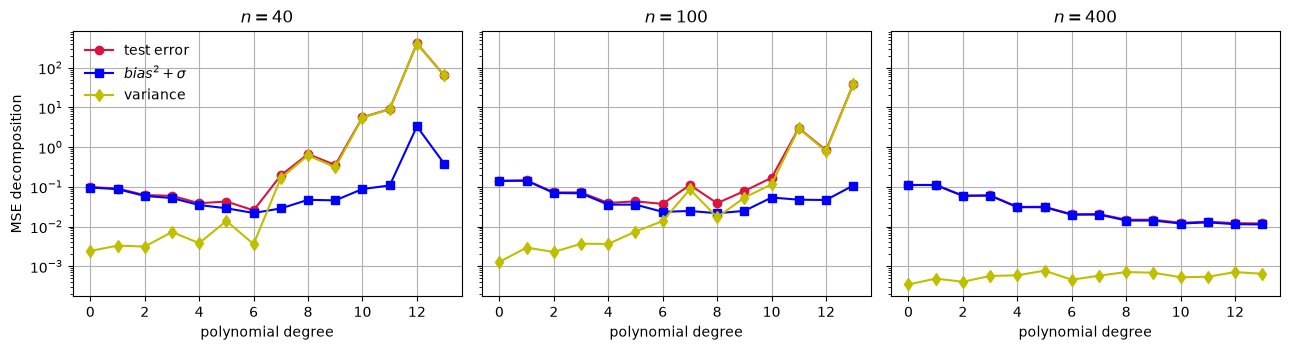

In [24]:
np.random.seed(2026)
def bias_variance_sweep(n=40, noise=0.1, maxdegree=14, n_bootstraps=100,
                        make_model=None, seed=2026):
    """Bootstrap estimate of error/bias^2/variance vs polynomial degree."""
    if make_model is None:
        make_model = lambda deg: make_pipeline(
            PolynomialFeatures(degree=deg), LinearRegression(fit_intercept=False))
    np.random.seed(seed)
    
    rng = np.random.default_rng(2026)
    x = np.sort(rng.uniform(-1,1,n))
    x = np.asarray(x).reshape(-1, 1)
    y = runge(x) + rng.normal(0, noise, size = (n, 1))
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=seed)

    error, bias, variance = (np.zeros(maxdegree) for _ in range(3))
    for degree in range(maxdegree):
        model = make_model(degree)
        y_pred = np.empty((y_test.shape[0], n_bootstraps))
        for i in range(n_bootstraps):
            x_, y_ = resample(x_train, y_train)
            y_pred[:, i] = model.fit(x_, y_).predict(x_test).ravel()
        error[degree] = np.mean(np.mean((y_test - y_pred)**2, axis=1, keepdims=True))
        bias[degree] = np.mean((y_test - np.mean(y_pred, axis=1, keepdims=True))**2)
        variance[degree] = np.mean(np.var(y_pred, axis=1, keepdims=True))
    return error, bias, variance


fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), sharey=True)
for ax, n_ in zip(axes, (40, 100, 400)):
    err, b2, var = bias_variance_sweep(n=n_)
    ax.plot(range(14), err, "o-", color="crimson", label="test error")
    ax.plot(range(14), b2, "s-", color="b", label=r"$bias^2 + \sigma$")
    ax.plot(range(14), var, "d-", color="y", label="variance")
    ax.set_yscale("log")
    ax.grid(True)
    ax.set_title(f"$n = {n_}$")
    ax.set_xlabel("polynomial degree")
axes[0].set_ylabel("MSE decomposition")
axes[0].legend(frameon=False)
plt.tight_layout()
plt.show()

In [27]:
degree_fixed = 11
lams = [0.0, 1e-4, 1e-1, 10.0]
rows = []

print(f"degree {degree_fixed}, n = 100, 100 bootstraps")
print(f"{'lambda':>8}  {'error':>10}  {'bias^2':>10}  {'variance':>10}")
for lam in lams:
    if lam == 0.0:
        mk = lambda deg: make_pipeline(PolynomialFeatures(degree=deg), LinearRegression(fit_intercept=False))
    else:
        mk = lambda deg, lam=lam: make_pipeline(PolynomialFeatures(degree=deg), StandardScaler(),Ridge(alpha=lam))
    err, b2, var = bias_variance_sweep(n=40, maxdegree=degree_fixed + 1, make_model=mk)
    d = degree_fixed
    rows.append({rf"Metode / $lambda$": "OLS" if lam == 0.0 else f"{lam:g}","Error": err[d],rf"Bias^{2}": b2[d], "Varians": var[d]})
    

table_lambda = pd.DataFrame(rows)
display(table_lambda.style.format({"Error": "{:.4f}","Bias": "{:.4f}","Varians": "{:.4f}"}).hide(axis="index"))

degree 11, n = 100, 100 bootstraps
  lambda       error      bias^2    variance


Metode / $lambda$,Error,Bias^2,Varians
OLS,9.0619,0.108027,8.9539
0.0001,0.0422,0.026304,0.0159
0.1,0.0307,0.027131,0.0035
10,0.0654,0.062934,0.0025


D: Cross-validation as a resampling technique
-

In [3]:
mx_degree = 15
rng = np.random.default_rng(2026)
n = 100
sigma = 0.1
x = np.sort(rng.uniform(-1,1,n))
y = runge(x) + rng.normal(0, sigma,n)

def ols_k_fold(x,y, mx_degree, n_splits=5):
    x = np.asarray(x).reshape(-1, 1)
    y = np.asarray(y).ravel()
    kf = KFold(n_splits, shuffle = True, random_state=2026)
    cv_mse = np.zeros(mx_degree)
    for deg in range(mx_degree):
        pipe = make_pipeline(PolynomialFeatures(degree = deg), LinearRegression(fit_intercept=False))
        scores = -cross_val_score(pipe, x, y.ravel(), cv = kf, scoring="neg_mean_squared_error")
        cv_mse[deg] = scores.mean() 

    return cv_mse

CV selects degree 11 (CV-MSE 0.0211129064)
CV selects degree 11 (CV-MSE 0.0202372654)


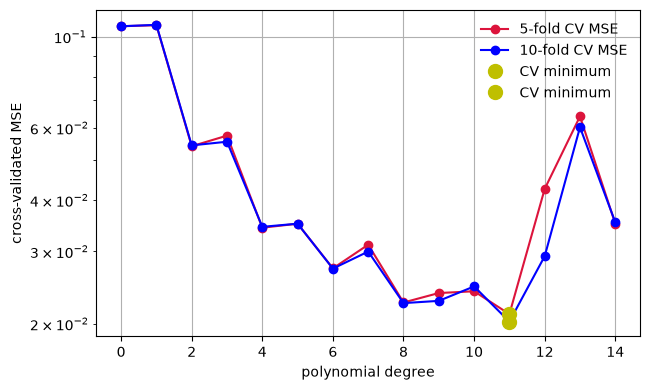

In [43]:
cv_mse5 = ols_k_fold(x,y, mx_degree, n_splits=5)
cv_mse10 = ols_k_fold(x,y, mx_degree, n_splits=10)

best_deg5 = np.argmin(cv_mse5)
best_deg10 = np.argmin(cv_mse10)

print(f"CV selects degree {best_deg5} (CV-MSE {cv_mse5[best_deg5]:.10f})")
print(f"CV selects degree {best_deg10} (CV-MSE {cv_mse10[best_deg10]:.10f})")

fig, ax = plt.subplots(figsize=(6.6, 4.0))
ax.plot(range(mx_degree), cv_mse5, "o-", color='crimson', label="5-fold CV MSE")
ax.plot(range(mx_degree), cv_mse10, "o-", color='b', label="10-fold CV MSE")
ax.plot(best_deg5, cv_mse5[best_deg5], "o", color='y', ms=10, label="CV minimum")
ax.plot(best_deg10, cv_mse10[best_deg10], "o", color='y', ms=10, label="CV minimum")
ax.set_yscale("log")
ax.grid()
ax.set_xlabel("polynomial degree")
ax.set_ylabel("cross-validated MSE")
ax.legend(frameon=False);plt.tight_layout()
plt.show()

From the figure one observes that the cv selects degree 11 as the optimal degree for both k_fold equal to 5 and 10. This is quite different from the OLS that gave 5 and the bootstrap suggested degree 6. 

In [46]:
degrees_ols = np.arange(mx_degree)  # Funksjonen din bruker range(mx_degree)

ols_table = pd.DataFrame({
    "Grad": degrees_ols,
    "5-fold CV-MSE": cv_mse5,
    "10-fold CV-MSE": cv_mse10
})

display(ols_table.style.format({
    "5-fold CV-MSE": "{:.6f}",
    "10-fold CV-MSE": "{:.6f}"
}).hide(axis="index"))

Grad,5-fold CV-MSE,10-fold CV-MSE
0,0.106075,0.106066
1,0.106692,0.106914
2,0.054127,0.054381
3,0.057439,0.055511
4,0.034275,0.034442
5,0.035044,0.035054
6,0.027285,0.027247
7,0.031159,0.029984
8,0.022533,0.022454
9,0.023761,0.022740


In [4]:
def RIDGE_k_fold(x, y, nlambdas, lambdas, k=5, degree=12):
    x = np.asarray(x).reshape(-1, 1)
    y = np.asarray(y).ravel()
    
    mse_kr = np.zeros(nlambdas)
    std_kr = np.zeros(nlambdas)

    kfold = KFold(n_splits=k, shuffle=True, random_state=2026)
    
    for i, lmb in enumerate(lambdas):
        pipe = make_pipeline(PolynomialFeatures(degree=degree), StandardScaler(), Ridge(alpha=lmb))
        scores = cross_val_score(pipe,x, y, cv = kfold, scoring="neg_mean_squared_error")
        mse_kr[i] = np.mean(-scores)
        std_kr[i] = scores.std()
    return mse_kr, std_kr

In [ ]:
rng = np.random.default_rng(2026)
sigma = 0.1
n = 100
x = np.sort(rng.uniform(-1,1,n))
y = runge(x) + rng.normal(0, sigma, size = n)   
nlam = n
lambdas = np.logspace(-7, 5, n)
degrees = np.arange(1, 14)

#kf_data = np.zeros(len(degrees), len(lambdas))
kf_mse = np.zeros((len(degrees), nlam))
kf_std = np.zeros((len(degrees), nlam))

for i, deg in enumerate(degrees):
    #for j, l in enumerate(lambdas):
    kf_mse5, kf_std5 = RIDGE_k_fold(x, y, nlam, lambdas=lambdas, k=5, degree=deg)
    kf_mse[i, :] = kf_mse5
    kf_std[i, :] = kf_std5

best_i, best_j = np.unravel_index(np.argmin(kf_mse), kf_mse.shape)

best_d = degrees[best_i]
best_l = lambdas[best_j]
best_mse = kf_mse[best_i, best_j]
best_std = kf_std[best_i, best_j]

print(f"Beste grad: {best_d}")
print(f"Beste lambda: {best_l:.4g}")
print(f"Beste CV-MSE: {best_mse:.5f}")
print(f"Standardavik mellom kfoldene: {best_std:.5f}")

Beste grad: 12
Beste lambda: 2.009e-05
Beste CV-MSE: 0.02068
Standardavik mellom kfoldene: 0.00534


In [35]:
rows = []

for i, deg in enumerate(degrees):
    best_j_for_degree = np.argmin(kf_mse[i, :])

    rows.append({
        "Grad": deg,
        "lambda": lambdas[best_j_for_degree],
        "CV-MSE": kf_mse[i, best_j_for_degree],
        "Spread": kf_std[i, best_j_for_degree]
    })

ridge_table = pd.DataFrame(rows)

display(ridge_table.style.format({
    "Beste lambda": "{:.4g}",
    "CV-MSE": "{:.5f}",
    "Spread": "{:.5f}"
}))

,Grad,lambda,CV-MSE,Spread
0,1,100000.000000,0.10608,0.02158
1,2,2.477076,0.05406,0.01159
2,3,10.000000,0.05561,0.01172
3,4,0.114976,0.03423,0.00746
4,5,0.265609,0.03452,0.00756
5,6,0.021544,0.02681,0.00429
6,7,0.037649,0.02765,0.00467
7,8,0.000433,0.02240,0.00356
8,9,0.000572,0.02316,0.00289
9,10,0.000107,0.02223,0.00270


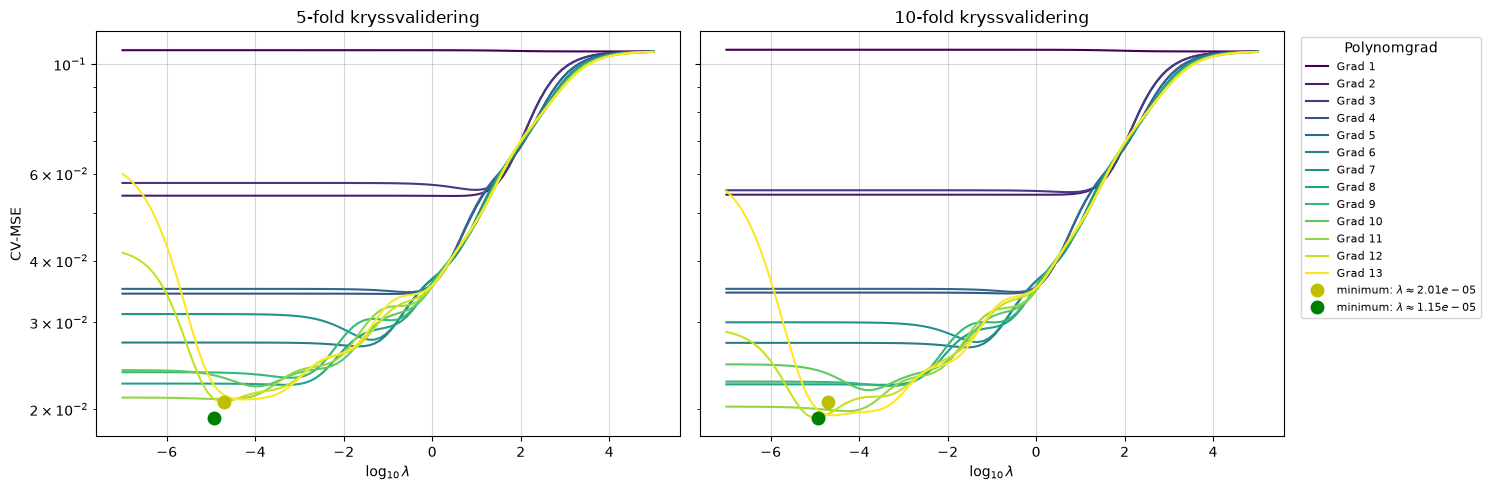

In [41]:
degrees = np.arange(1, 14)

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
colors = plt.cm.viridis(np.linspace(0, 1, len(degrees)))
mse_sklearn5, _ = RIDGE_k_fold(x, y, nlam, lambdas, k=5, degree=12)
mse_sklearn10, _ = RIDGE_k_fold(x, y, nlam, lambdas, k=10, degree=12)

best5 = np.argmin(mse_sklearn5)
best10 = np.argmin(mse_sklearn10)

for ax, k in zip(axes, [5, 10]):
    for deg, color in zip(degrees, colors):
        mse, _ = RIDGE_k_fold(x, y, nlam, lambdas, k=k, degree=deg)
        ax.plot(np.log10(lambdas), mse,color=color, lw=1.5, label=f"Grad {deg}")
    ax.plot(np.log10(lambdas[best5]), mse_sklearn5[best5], "o", color='y', ms=9,label=rf"minimum: $\lambda\approx{lambdas[best5]:.3g}$")
    ax.plot(np.log10(lambdas[best10]), mse_sklearn10[best10], "o", color='green', ms=9,label=rf"minimum: $\lambda\approx{lambdas[best10]:.3g}$")
    #ax.axhline(sigma**2, color="gray", ls=":",label=r"Støyvarians $\sigma^2$")
    ax.set_title(f"{k}-fold kryssvalidering")
    ax.set_xlabel(r"$\log_{10}\lambda$")
    ax.set_yscale("log")
    ax.grid(alpha=0.5)

axes[0].set_ylabel("CV-MSE")
axes[1].legend(title="Polynomgrad", bbox_to_anchor=(1.02, 1),loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

best lambda 2.009e-05, cross-validated MSE 0.0207
best lambda 1.15e-05, cross-validated MSE 0.0192


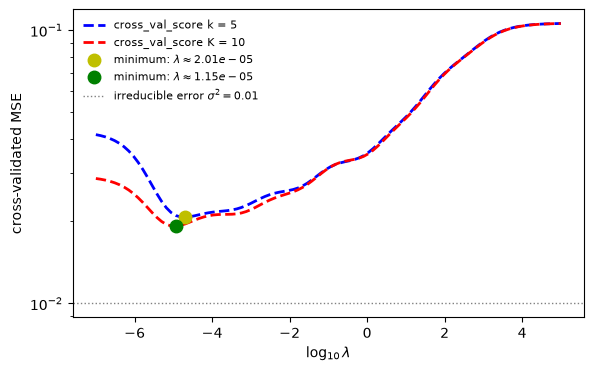

In [32]:

mse_sklearn5, _ = RIDGE_k_fold(x, y, nlam, lambdas, k=5, degree=12)
mse_sklearn10, _ = RIDGE_k_fold(x, y, nlam, lambdas, k=10, degree=12)

best5 = np.argmin(mse_sklearn5)
best10 = np.argmin(mse_sklearn10)

print(f"best lambda {lambdas[best5]:.4g}, cross-validated MSE {mse_sklearn5[best5]:.4f}")
print(f"best lambda {lambdas[best10]:.4g}, cross-validated MSE {mse_sklearn10[best10]:.4f}")

fig, ax = plt.subplots(figsize=(6.6, 4.0))

ax.plot(np.log10(lambdas), mse_sklearn5, "--", color='b', lw=2,label="cross_val_score k = 5")
ax.plot(np.log10(lambdas), mse_sklearn10, "--", color='r', lw=2,label="cross_val_score K = 10")

ax.plot(np.log10(lambdas[best5]), mse_sklearn5[best5], "o", color='y', ms=9,label=rf"minimum: $\lambda\approx{lambdas[best5]:.3g}$")
ax.plot(np.log10(lambdas[best10]), mse_sklearn10[best10], "o", color='green', ms=9,label=rf"minimum: $\lambda\approx{lambdas[best10]:.3g}$")

ax.axhline(sigma**2, color="gray", lw=1, ls=":", label=rf"irreducible error $\sigma^2={sigma**2:.2f}$")
ax.set_yscale("log")
ax.set_xlabel(r"$\log_{10}\lambda$")
ax.set_ylabel("cross-validated MSE")
ax.legend(frameon=False, fontsize= 8)
plt.show()

Exercise E:Writing your own gradient descent code, with analytical gradients
and automatic differentiation
-

In [5]:
import jax
import jax.numpy as jnp
jax.config.update("jax_enable_x64", True)
import optax

In [6]:
def closed_form(X, y, lam=0.0):
    """(X^T X + n lambda I)^-1 X^T y, the 1/n convention of Eq. (3.95)."""
    n, p = X.shape
    return np.linalg.solve(X.T @ X + n * lam * np.eye(p), X.T @ y)

def cost(theta, X, y, lam=0.0):
    """Eqs. (4.12) and (4.16)."""
    return np.sum((X @ theta - y) ** 2) / len(y) + lam * theta @ theta

def gradient(theta, X, y, lam=0.0):
    """Eqs. (4.13) and (4.17): your analytical gradient from last week (or jax.grad of cost)."""
    n = len(y)
    return (2.0 / n) * X.T @ (X @ theta - y) + 2.0 * lam * theta


In [7]:
#deg = 10
#scaler = StandardScaler()
theta, Xtr_sc, Xte_sc, y_train, y_test = exercisedata(x, y, d, sigma, n)


In [8]:


jax.config.update("jax_enable_x64", True)

def cost_jax(theta, X, y, lam=0.0):
    error = X @ theta - y
    return jnp.mean(error**2) + lam * jnp.sum(theta**2)

gradient_jax = jax.grad(cost_jax, argnums=0)
def automatic_gradient(theta, X, y, lam=0.0):
    grad = gradient_jax(jnp.asarray(theta),jnp.asarray(X),jnp.asarray(y),lam)

    return np.asarray(grad)

In [40]:
theta0 = np.zeros(Xtr_sc.shape[1])

# OLS
grad_analytical_ols = gradient(theta0, Xtr_sc, y_train, lam=0.0)
grad_jax_ols = automatic_gradient( theta0, Xtr_sc, y_train, lam=0.0)

print( "Difference between analytical OLS and JAX OLS:",np.max(np.abs(grad_analytical_ols - grad_jax_ols)))

# Ridge
grad_analytical_ridge = gradient(theta0, Xtr_sc, y_train, lam=0.1)
grad_jax_ridge = automatic_gradient(theta0, Xtr_sc, y_train, lam=0.1)

print("Difference between analytical Ridge and JAX Ridge:",np.max(np.abs(grad_analytical_ridge - grad_jax_ridge)))

Difference between analytical OLS and JAX OLS: 1.1102230246251565e-16
Difference between analytical Ridge and JAX Ridge: 1.1102230246251565e-16


A diffrence of -16 indicate to machine persission.

In [9]:
def hessian(X, lam =0.0):
    n = X.shape[0]
    I = np.eye(X.shape[1])
    H =  (2/n)*(X.T@X) + 2*lam*I
    return H

def eigenvalues_minmax(X, lam=0.0):
    H = hessian(X, lam =lam)
    
    eigenvalues = np.linalg.eigvals(H)
    lmin = eigenvalues.min()
    lmax = eigenvalues.max()
    
    kappa = lmax/lmin
    gamma_opt = 2/(lmin + lmax)
    
    gamma_be = 0.99/lmax
    
    gammaA = 1.02*2/lmax
    
    return lmin, lmax, kappa, gamma_opt, gamma_be, gammaA

def grad_decent(X,y,gamma, grad_func,lam=0.0,num_iters=10000,tol=1e-6):
    X = np.asarray(X)
    y = np.asarray(y).ravel()

    n, p = X.shape
    I = np.eye(p)

    # Startverdi
    theta_gd = np.zeros(p)

    grad_length = []
    difference = []

    # Lukket løsning
    if lam == 0:
        # lstsq er tryggere enn solve dersom X.T @ X er singulær
        theta_closed = np.linalg.lstsq(X, y, rcond=None)[0]
    else:
        theta_closed = np.linalg.solve( X.T @ X + n * lam * I, X.T @ y)
    # Standardverdi dersom metoden ikke konvergerer
    iterations = num_iters

    for t in range(num_iters):

        # Gradient beregnet med funksjonen vi sender inn
        grad = np.asarray(grad_func(theta_gd, X, y, lam))

        # Oppdater parameterne
        theta_gd = theta_gd - gamma * grad

        # Mål etter oppdateringen
        grad_l = np.linalg.norm(grad_func(theta_gd, X, y, lam))
        diff = np.linalg.norm(theta_gd - theta_closed)

        grad_length.append(grad_l)
        difference.append(diff)

        # Samme stoppkriterium for OLS og Ridge
        if grad_l < tol and diff < tol:
            iterations = t + 1
            print(f"gamma = {gamma}: "f"Konvergerte etter {t + 1} iterasjoner")
            break

    else:
        print(f"gamma = {gamma}: "f"Konvergerte ikke etter {num_iters} iterasjoner")

    return theta_gd, theta_closed, difference, grad_length, iterations

In [ ]:
rows = []
for lam in [0.0, 0.1]:
    print("\nAnalytical OLS" if lam == 0 else "\nAnalytical Ridge")
    lmin, lmax, kappa, gamma_opt, _, _ = (eigenvalues_minmax(Xtr_sc, lam=lam))
    theta_gd, theta_closed, difference, grad_length, iterations = (grad_decent(Xtr_sc,y_train,gamma=gamma_opt,grad_func=gradient,lam=lam))
    rows.append({"Method": "OLS" if lam == 0 else "Ridge",r"$\lambda$": lam,
        r"$\lambda_{min}$": lmin,
        r"$\lambda_{max}$": lmax,
        r"$\kappa$": kappa,
        r"$\gamma_{opt}$": gamma_opt,
        "Iteration": iterations,
        "Diffrence": difference[-1]
    })

table_gd = pd.DataFrame(rows)

display(table_gd.style.format({
    "$\lambda$": "{:.1f}",
    r"$\lambda_{min}$": "{:.3g}",
    r"$\lambda_{max}$": "{:.3g}",
    r"$\kappa$": "{:.3g}",
    r"$\gamma_{opt}$": "{:.3g}",
    "Difference": "{:.3g}"
}))


Analytical OLS
gamma = 0.12936962782870715: Konvergerte ikke etter 10000 iterasjoner

Analytical Ridge
gamma = 0.12610675113646463: Konvergerte etter 516 iterasjoner


,Method,$\lambda$,$\lambda_{min}$,$\lambda_{max}$,$\kappa$,$\gamma_{opt}$,Iteration,Diffrence
0,OLS,0.0,3.9e-07,15.5,3.96e+07,0.129,10000,66.171850
1,Ridge,0.1,0.2,15.7,78.3,0.126,516,0.000000


In [ ]:
rows = []
for lam in [0.0, 0.1]:
    print("\nAutomatic OLS" if lam == 0 else "\nAutomatic Ridge")

    lmin, lmax, kappa, gamma_opt, _, _ = (eigenvalues_minmax(Xtr_sc, lam=lam))
    theta_gd, theta_closed, difference, grad_length, iterations = (grad_decent(Xtr_sc,y_train,gamma=gamma_opt,grad_func=automatic_gradient,lam=lam))
    rows.append({"Method": "OLS" if lam == 0 else "Ridge",r"lambda": lam,
            r"lambda_{min}": lmin,
            r"lambda_{max}": lmax,
            r"kappa$": kappa,
            r"gamma_{opt}": gamma_opt,
            "Iteration": iterations,
            "Diffrence": difference[-1]})
    
    
table_gd = pd.DataFrame(rows)

display(table_gd.style.format({
    "lambda": "{:.1f}",
    r"lambda_{min}": "{:.3g}",
    r"lambda_{max}": "{:.3g}",
    r"kappa": "{:.3g}",
    r"gamma_{opt}": "{:.3g}",
    "Difference": "{:.3g}"}))
  


Automatic OLS
gamma = 0.12936962782870715: Konvergerte ikke etter 10000 iterasjoner

Automatic Ridge
gamma = 0.12610675113646463: Konvergerte etter 516 iterasjoner


,Method,$\lambda$,lambda_{min},lambda_{max},kappa$,gamma_{opt},Iteration,Diffrence
0,OLS,0.000000,3.9e-07,15.5,39601936.633569,0.129,10000,66.171850
1,Ridge,0.100000,0.2,15.7,78.297741,0.126,516,0.000000


In [ ]:
from IPython.display import display, Math

rows = []
#Analytisk
for lam in [0.0, 0.1]:
    method = "OLS" if lam == 0 else "Ridge"
    lmin, lmax, kappa, gamma_opt, _, _ = eigenvalues_minmax(Xtr_sc, lam=lam)
    gamma_limit = 2 / lmax

    gammas = {"Liten": 0.1 * gamma_opt,"Optimal": gamma_opt,"Under grensen": 0.99 * gamma_limit,"Over grensen": 1.02 * gamma_limit,}

    for gamma_name, gamma in gammas.items():
        theta_gd, theta_closed, difference, grad_length, iterations = grad_decent(Xtr_sc, y_train,gamma=gamma,grad_func=gradient,lam=lam)

        rows.append({
            "Method": method,
            "Gamma choice": gamma_name,
            "Lambda": lam,
            "Gamma": gamma,
            "Iterations": iterations,
            "Difference": difference[-1],
            "Gradient norm": grad_length[-1]})

table_gamma = pd.DataFrame(rows)

headers = [r"\text{Method}", r"\text{Gamma choice}", r"\lambda", r"\gamma",r"\text{Iterations}", r"\text{Difference}", r"\|\nabla C\|"]
lines = [r"\begin{array}{llrrrrr}"," & ".join(headers) + r" \\ \hline"]

for row in rows:
    values = [
        rf"\text{{{row['Method']}}}",
        rf"\text{{{row['Gamma choice']}}}",
        f"{row['Lambda']:.1f}",
        f"{row['Gamma']:.3g}",
        str(row["Iterations"]),
        f"{row['Difference']:.3g}",
        f"{row['Gradient norm']:.3g}",]
    lines.append(" & ".join(values) + r" \\")

lines.append(r"\end{array}")
display(Math("\n".join(lines)))

gamma = 0.012936962782870716: Konvergerte ikke etter 10000 iterasjoner
gamma = 0.12936962782870715: Konvergerte ikke etter 10000 iterasjoner
gamma = 0.1280759347845026: Konvergerte ikke etter 10000 iterasjoner


C:\Users\torae\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\numpy\linalg\_linalg.py:2768: RuntimeWarning: overflow encountered in dot
  sqnorm = x.dot(x)


gamma = 0.13195702371736634: Konvergerte ikke etter 10000 iterasjoner
gamma = 0.012610675113646464: Konvergerte etter 4264 iterasjoner
gamma = 0.12610675113646463: Konvergerte etter 516 iterasjoner
gamma = 0.12644018280400285: Konvergerte etter 653 iterasjoner
gamma = 0.13027170349503323: Konvergerte ikke etter 10000 iterasjoner


<IPython.core.display.Math object>

In [ ]:
for lam in [0.0, 0.1]:

    model = "Automatic OLS" if lam == 0 else "Automatic Ridge"
    print(f"\n---------- {model} ----------")

    lmin, lmax, kappa, gamma_opt, _, _ = (eigenvalues_minmax(Xtr_sc, lam=lam))

    gamma_limit = 2 / lmax

    gammas = {"liten": 0.1 * gamma_opt,"optimal": gamma_opt,"under grensen": 0.99 * gamma_limit,"over grensen": 1.02 * gamma_limit}

    print("lambda_min:", lmin)
    print("lambda_max:", lmax)
    print("kappa:", kappa)
    print("gamma_opt:", gamma_opt)
    print("stabilitetsgrense:", gamma_limit)

    for gamma_name, gamma in gammas.items():

        print(f"\n{gamma_name}, gamma = {gamma}")

        theta_gd, theta_closed, difference, grad_length, iterations = (grad_decent(Xtr_sc,y_train,gamma=gamma,grad_func=automatic_gradient,lam=lam))

        print("Iterasjoner:", iterations)
        print("Sluttforskjell:", difference[-1])
        print("Gradientlengde:", grad_length[-1])


---------- Automatic OLS ----------
lambda_min: 3.903743116089475e-07
lambda_max: 15.45957875171084
kappa: 39601936.633569464
gamma_opt: 0.12936962782870715
stabilitetsgrense: 0.12936963109545718

liten, gamma = 0.012936962782870716
gamma = 0.012936962782870716: Konvergerte ikke etter 10000 iterasjoner
Iterasjoner: 10000
Sluttforskjell: 66.37098727866878
Gradientlengde: 0.004872267817385571

optimal, gamma = 0.12936962782870715
gamma = 0.12936962782870715: Konvergerte ikke etter 10000 iterasjoner
Iterasjoner: 10000
Sluttforskjell: 66.17185031518075
Gradientlengde: 0.5267291437283494

under grensen, gamma = 0.1280759347845026
gamma = 0.1280759347845026: Konvergerte ikke etter 10000 iterasjoner
Iterasjoner: 10000
Sluttforskjell: 66.17381543818858
Gradientlengde: 0.0007794091313947012

over grensen, gamma = 0.13195702371736634
gamma = 0.13195702371736634: Konvergerte ikke etter 10000 iterasjoner
Iterasjoner: 10000
Sluttforskjell: inf
Gradientlengde: inf

---------- Automatic Ridge ------

In [50]:

rows_auto = []

for lam in [0.0, 0.1]:
    method = "Automatic OLS" if lam == 0 else "Automatic Ridge"
    lmin, lmax, kappa, gamma_opt, _, _ = eigenvalues_minmax(Xtr_sc, lam=lam)
    gamma_limit = 2 / lmax

    gammas = {"Liten": 0.1 * gamma_opt, "Optimal": gamma_opt,"Under grensen": 0.99 * gamma_limit,"Over grensen": 1.02 * gamma_limit,}

    for gamma_name, gamma in gammas.items():
        theta_gd, theta_closed, difference, grad_length, iterations = grad_decent(Xtr_sc, y_train,gamma=gamma,grad_func=automatic_gradient,lam=lam)

        rows_auto.append({"Method": method,"Gamma choice": gamma_name,"Lambda": lam,"Gamma": gamma,"Iterations": iterations,"Difference": difference[-1],"Gradient norm": grad_length[-1],})

table_auto = pd.DataFrame(rows_auto)

headers = [r"\text{Method}", r"\text{Gamma choice}", r"\lambda", r"\gamma", r"\text{Iterations}", r"\text{Difference}", r"\|\nabla C\|"]
lines = [r"\begin{array}{llrrrrr}", " & ".join(headers) + r" \\ \hline"]

for row in rows_auto:
    values = [rf"\text{{{row['Method']}}}",rf"\text{{{row['Gamma choice']}}}",f"{row['Lambda']:.1f}",f"{row['Gamma']:.3g}",str(row["Iterations"]),f"{row['Difference']:.3g}",f"{row['Gradient norm']:.3g}",]
    lines.append(" & ".join(values) + r" \\")

lines.append(r"\end{array}")
display(Math("\n".join(lines)))

gamma = 0.012936962782870716: Konvergerte ikke etter 10000 iterasjoner
gamma = 0.12936962782870715: Konvergerte ikke etter 10000 iterasjoner
gamma = 0.1280759347845026: Konvergerte ikke etter 10000 iterasjoner
gamma = 0.13195702371736634: Konvergerte ikke etter 10000 iterasjoner
gamma = 0.012610675113646464: Konvergerte etter 4264 iterasjoner
gamma = 0.12610675113646463: Konvergerte etter 516 iterasjoner
gamma = 0.12644018280400285: Konvergerte etter 653 iterasjoner
gamma = 0.13027170349503323: Konvergerte ikke etter 10000 iterasjoner


<IPython.core.display.Math object>

F Including momentum and more advanced ways to update the learning rate
-

In [10]:
def runge_data(n=100, degree=6, noise=0.1, seed=2026):
    """Runge function 1/(1+25x^2) on [-1,1], standardised polynomial features, centred y."""
    rng = np.random.default_rng(seed)
    x = rng.uniform(-1.0, 1.0, n)
    y = 1.0 / (1.0 + 25.0 * x**2) + noise * rng.standard_normal(n)
    X = np.column_stack([x**k for k in range(1, degree + 1)])
    X_norm = (X - X.mean(axis=0)) / X.std(axis=0)
    return X_norm, y - y.mean()

def optimiser_step(method, theta, g, state, t, gamma, beta=0.9, rho=0.99,beta1=0.9, beta2=0.999, eps=1e-8):
    """One update of theta from the gradient g at step t = 1, 2, ...; state carries the running quantities."""
    if method == "plain":                                    # Eq. (4.10)
        return theta - gamma * g, state
    if method == "momentum":                                 # Eq. (4.28)
        state["v"] = v = beta * state.get("v", 0.0) + gamma * g 
        return theta - v, state
    if method == "adagrad":                                  # Eqs. (4.42) and (4.45)
        state["r"] = r = state.get("r", 0.0) + g * g
        return theta - gamma * g / (np.sqrt(r) + eps), state
    if method == "rmsprop":                                  # Eqs. (4.47) and (4.48)
        state["r"] = r = rho * state.get("r", 0.0) + (1.0 - rho) * g * g 
        return theta - gamma * g / (np.sqrt(r) + eps), state
    if method == "adam":                                     # Eqs. (4.51), (4.52), (4.54), (4.55)
        state["m"] = m =  beta1 * state.get("m", 0.0) + (1.0 - beta1) * g
        state["r"] = r = beta2 * state.get("r", 0.0) + (1.0 - beta2) * g * g
        m_hat, r_hat = m / (1.0 - beta1**t), r / (1.0 - beta2**t)
        return theta - gamma * m_hat / (np.sqrt(r_hat) + eps), state
    raise ValueError(f"unknown method {method}")

def optimise(grad, theta0, method, gamma, num_iters=1000, tol=1e-8, **kw):
    """Full-gradient loop; returns all iterates and the number of steps taken."""
    theta, state = np.array(theta0, dtype=float), {}
    
    history = [theta.copy()]
    for t in range(1, num_iters + 1):
        with np.errstate(over="ignore", invalid="ignore"):
            g = grad(theta)
        #g = grad(theta)
        if not np.all(np.isfinite(g)):
            break
        theta, state = optimiser_step(method, theta, g, state, t, gamma, **kw)
        if not np.all(np.isfinite(theta)):
            break

        history.append(theta.copy())
        if np.linalg.norm(g) < tol:
            break
    return np.array(history), t


def runge_comparison(runs, degree=10, num_iters=30000, tol_dist = 1e-8):
    """Excess cost C(theta_k) - C(theta_hat) for the five optimisers on the Runge problem."""
    X, y = runge_data(n=100, degree=degree, noise=0.1, seed=2026)#exercise_data(n=100, degree=degree, noise=0.5, seed=2026)    #Finne ut hvordan man skal gjre denne her.. 
    results = {}
    for lam in (0.0, 0.01):
        theta_cf = closed_form(X, y, lam)
        min_cost = cost(theta_cf, X,y,lam)
        grad = lambda theta: gradient(theta, X, y, lam)
        H = hessian(X, lam)
        eigenvalues = np.linalg.eigvalsh(H)
        lmax = eigenvalues.max()
        gamma_gd = 0.9 * 2.0 / lmax
        for method, gamma in runs:
            g = gamma_gd if gamma is None else gamma
            theta0 = np.zeros(X.shape[1])
            #path, steps = optimise(grad, theta0, method, g, num_iters=num_iters)
            path, steps = optimise(grad,theta0,method,g,num_iters=num_iters)
            distances = np.array([np.linalg.norm(theta_k - theta_cf) for theta_k in path])
            costs = np.array([cost(theta_k, X, y, lam)for theta_k in path])
            excess_cost = costs - min_cost
            results[(lam, method, g)] = {"distances": distances,"excess_cost": excess_cost, "final_cost": costs[-1],"steps": steps,"final_distance": distances[-1], "converged": distances[-1] < tol_dist}

    return results

In [ ]:
#Test1. Antall iterasjoner for å nå en viss nøyaktighet.
#the number of iterations needed to reach a given accuracy relative to the closed-form solution,and in terms of their sensitivity to the choice of the (initial) learning rate.

In [52]:
runs = (("momentum", None),("adagrad", 0.001),("adagrad", 0.01),("adagrad", 0.1),("rmsprop", 0.001),("rmsprop", 0.01),("rmsprop", 0.1),("adam", 0.001), ("adam", 0.01), ("adam", 0.1))
results = runge_comparison(runs,degree=10,num_iters=30000, tol_dist = 1e-6)
headers = [r"\lambda", r"\text{Method}", r"\gamma",r"\text{Steps}", r"\text{Distance}", r"\text{Converged}"]
lines = [r"\begin{array}{rlrrrc}"," & ".join(headers) + r" \\ \hline"]

for (lam, method, gamma), result in results.items():
    values = [f"{lam:g}", rf"\text{{{method}}}", f"{gamma:.5f}", str(result["steps"]), f"{result['final_distance']:.3e}",
        r"\text{Yes}" if result["converged"] else r"\text{No}",]
    lines.append(" & ".join(values) + r" \\")

lines.append(r"\end{array}")
display(Math("\n".join(lines)))

<IPython.core.display.Math object>

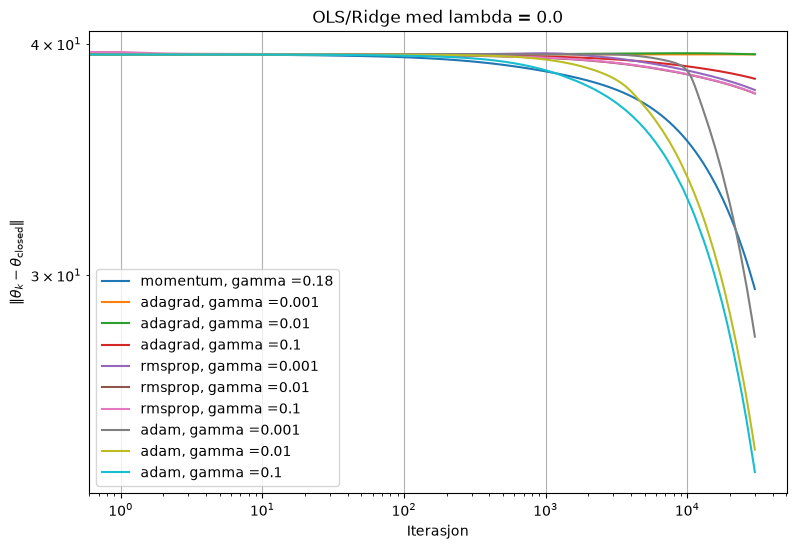

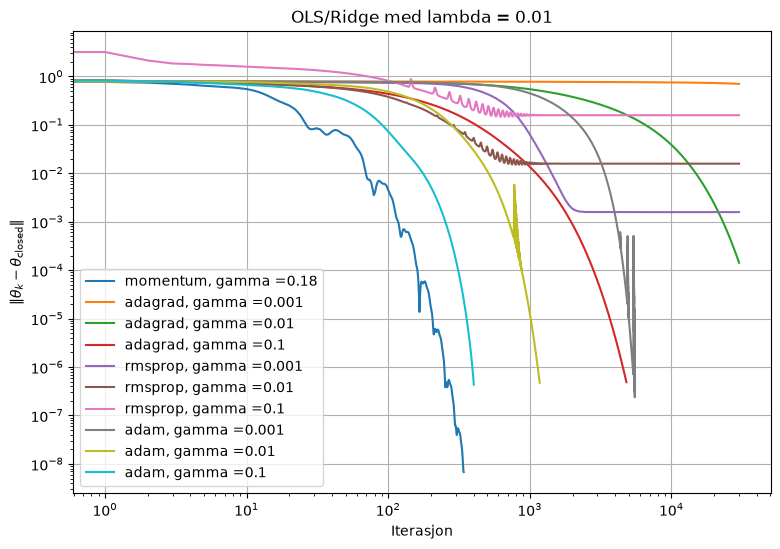

In [53]:

for lam in (0.0, 0.01):
    plt.figure(figsize=(9, 6))

    for (current_lam, method, gamma), result in results.items():
        if current_lam == lam:
            plt.loglog(result["distances"],label=f"{method}, gamma ={gamma:.3g}")

    plt.xlabel("Iterasjon")
    plt.ylabel(r"$\|\theta_k-\theta_{\mathrm{closed}}\|$")
    plt.title(f"OLS/Ridge med lambda = {lam}")
    plt.legend()
    plt.grid(True)
    plt.show()

G Writing our own code for Lasso regression
-

In [11]:
def lasso_gradient(theta, X, y, lam):
    n = len(y)
    mse_grad = (2 / n) * X.T @ (X @ theta - y)
    penalty_grad = lam * np.sign(theta)
    penalty_grad[0] = 0.0       # Ikke straff konstantleddet/interceptet

    return mse_grad + penalty_grad

x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.3,random_state=2026)


y_train = np.asarray(y_train).ravel()
y_test = np.asarray(y_test).ravel()
degree = 10
X_train = design_matrix(x_train, degree)
X_test = design_matrix(x_test, degree)
scaler = StandardScaler()
X_train_sc = X_train.copy()
X_test_sc = X_test.copy()
X_train_sc[:, 1:] = scaler.fit_transform(X_train[:, 1:])
X_test_sc[:, 1:] = scaler.transform(X_test[:, 1:])


lam = 0.01

grad_lasso = lambda theta: lasso_gradient(theta,X_train_sc,y_train,lam)
theta0 = np.zeros(X_train_sc.shape[1])

methods = ["momentum", "adagrad", "rmsprop", "adam"]


#optimaliseringsmetodene
for method in methods:

    theta_path, state = optimise(grad=grad_lasso,theta0=theta0.copy(), method=method, gamma=0.01, num_iters=10_000)

    theta_lasso = theta_path[-1]

    # Prediksjoner
    y_pred_train = X_train_sc @ theta_lasso
    y_pred_test = X_test_sc @ theta_lasso

    # MSE
    train_mse = np.mean((y_train - y_pred_train)**2)
    test_mse = np.mean((y_test - y_pred_test)**2)

    # Ikke tell interceptet
    n_exact_zero = np.sum(theta_lasso[1:] == 0)
    n_small = np.sum(np.abs(theta_lasso[1:]) < 1e-4)

    print(f"{method:8s}",f"train MSE: {train_mse:.6f}",f"test MSE: {test_mse:.6f}",f"exact zeros: {n_exact_zero}",f"near zeros: {n_small}")

momentum train MSE: 0.028167 test MSE: 0.048273 exact zeros: 0 near zeros: 1
adagrad  train MSE: 0.029207 test MSE: 0.050458 exact zeros: 0 near zeros: 4
rmsprop  train MSE: 0.029664 test MSE: 0.048377 exact zeros: 0 near zeros: 0
adam     train MSE: 0.028156 test MSE: 0.048011 exact zeros: 0 near zeros: 0


In [56]:
# Samme regulariseringsstyrke som i vår kostnadsfunksjon
alpha = lam / 2

# Vi fjerner konstantkolonnen fordi sklearn lager intercept selv
lasso_sklearn = Lasso( alpha=alpha, fit_intercept=True, max_iter=100_000, tol=1e-10)

lasso_sklearn.fit(X_train_sc[:, 1:],y_train)

# Samle intercept og koeffisienter i én theta-vektor
theta_sklearn = np.concatenate(([lasso_sklearn.intercept_],lasso_sklearn.coef_))
# Prediksjoner fra sklearn
y_pred_sklearn_train = lasso_sklearn.predict(X_train_sc[:, 1:])
y_pred_sklearn_test = lasso_sklearn.predict(X_test_sc[:, 1:])
# MSE
mse_sklearn_train = np.mean((y_train - y_pred_sklearn_train)**2)
mse_sklearn_test = np.mean((y_test - y_pred_sklearn_test)**2)
# Sammenlign med egen løsning
print("Egen theta:")
print(theta_lasso)

print("\nSklearn theta:")
print(theta_sklearn)

print("\nAvstand mellom koeffisientene:", np.linalg.norm(theta_lasso - theta_sklearn))
print("Sklearn train MSE:", mse_sklearn_train)
print("Sklearn test MSE:", mse_sklearn_test)
print( "Antall nuller i sklearn:", np.sum(theta_sklearn[1:] == 0))

Egen theta:
[ 3.63065115e-01  1.64479975e-02 -5.06551533e-01  1.38511819e-03
  3.08791651e-01  1.03105845e-04  8.44950058e-03  5.84097246e-04
  1.02973521e-03 -1.33769814e-03 -2.22192876e-04]

Sklearn theta:
[ 0.36306511  0.01887249 -0.50449947  0.          0.31511881  0.
  0.         -0.          0.         -0.          0.        ]

Avstand mellom koeffisientene: 0.01125546952068712
Sklearn train MSE: 0.02816615142970414
Sklearn test MSE: 0.048257419367898485
Antall nuller i sklearn: 7


In [58]:
lam = 0.01
grad_lasso = lambda theta: lasso_gradient(theta,X_train_sc,y_train,lam)
theta0 = np.zeros(X_train_sc.shape[1])

methods = ["momentum", "adagrad", "rmsprop", "adam"]
gammas = [0.0001, 0.001, 0.01, 0.1]

results = {}

for method in methods:
    results[method] = {}

    for gamma in gammas:

        theta_path, state = optimise(grad=grad_lasso,theta0=theta0.copy(),method=method,gamma=gamma,num_iters=10_000)

        theta_lasso = theta_path[-1]

        # Kontroller om metoden divergerte
        if not np.all(np.isfinite(theta_lasso)):
            results[method][gamma] = {"train_mse": np.nan,"test_mse": np.nan,"near_zero": 0,"diverged": True}

            print(f"{method:8s}, gamma={gamma}: divergerte")
            continue

        # Prediksjoner
        y_pred_train = X_train_sc @ theta_lasso
        y_pred_test = X_test_sc @ theta_lasso

        # MSE
        train_mse = np.mean((y_train - y_pred_train)**2)

        test_mse = np.mean((y_test - y_pred_test)**2)

        # Ikke inkluder interceptet
        near_zero = np.sum(np.abs(theta_lasso[1:]) < 1e-4)

        results[method][gamma] = {"train_mse": train_mse,"test_mse": test_mse,"near_zero": near_zero,"diverged": False,"theta": theta_lasso}

        print(f"{method:8s}",f"gamma={gamma:<7}",f"train MSE={train_mse:.6f}",f"test MSE={test_mse:.6f}",f"near zero={near_zero}")

momentum gamma=0.0001  train MSE=0.032825 test MSE=0.058198 near zero=4
momentum gamma=0.001   train MSE=0.029298 test MSE=0.050543 near zero=6
momentum gamma=0.01    train MSE=0.028167 test MSE=0.048273 near zero=1
momentum gamma=0.1     train MSE=0.028191 test MSE=0.048257 near zero=0
adagrad  gamma=0.0001  train MSE=0.183393 test MSE=0.217403 near zero=2
adagrad  gamma=0.001   train MSE=0.077558 test MSE=0.134792 near zero=4
adagrad  gamma=0.01    train MSE=0.029207 test MSE=0.050458 near zero=4
adagrad  gamma=0.1     train MSE=0.028175 test MSE=0.048310 near zero=1
rmsprop  gamma=0.0001  train MSE=0.028168 test MSE=0.048254 near zero=5
rmsprop  gamma=0.001   train MSE=0.028184 test MSE=0.048286 near zero=0
rmsprop  gamma=0.01    train MSE=0.029664 test MSE=0.048377 near zero=0
rmsprop  gamma=0.1     train MSE=0.274635 test MSE=0.127609 near zero=0
adam     gamma=0.0001  train MSE=0.029454 test MSE=0.050920 near zero=5
adam     gamma=0.001   train MSE=0.028170 test MSE=0.048224 near

In [61]:
lam_ridge = 0.01
lam_lasso = 0.01

gamma = 0.01
method = "adam"
num_iters = 10_000

theta0 = np.zeros(X_train_sc.shape[1])

gradient_functions = {
    "OLS": lambda theta: gradient(theta, X_train_sc, y_train, lam=0.0),
    "Ridge": lambda theta: gradient(theta, X_train_sc, y_train, lam=lam_ridge),
    "Lasso": lambda theta: lasso_gradient(theta, X_train_sc, y_train, lam=lam_lasso)}

results_models = {}

for model_name, grad_function in gradient_functions.items():

    theta_path, state = optimise(grad=grad_function,theta0=theta0.copy(),method=method,gamma=gamma,num_iters=num_iters)
    theta = theta_path[-1]

    y_pred_train = X_train_sc @ theta
    y_pred_test = X_test_sc @ theta

    train_mse = np.mean((y_train - y_pred_train)**2)
    test_mse = np.mean((y_test - y_pred_test)**2)

    results_models[model_name] = {"theta": theta,"theta_path": theta_path,"train_mse": train_mse,"test_mse": test_mse}
    print(f"{model_name:6s}",f"train MSE = {train_mse:.6f}",f"test MSE = {test_mse:.6f}",f"||theta||₁ = {np.sum(np.abs(theta[1:])):.4f}",f"||theta||₂ = {np.linalg.norm(theta[1:]):.4f}",f"near zero = {np.sum(np.abs(theta[1:]) < 1e-4)}")

OLS    train MSE = 0.015917 test MSE = 0.102973 ||theta||₁ = 11.0090 ||theta||₂ = 5.5516 near zero = 0
Ridge  train MSE = 0.026011 test MSE = 0.052500 ||theta||₁ = 1.4246 ||theta||₂ = 0.6784 near zero = 0
Lasso  train MSE = 0.028156 test MSE = 0.048011 ||theta||₁ = 0.8449 ||theta||₂ = 0.5935 near zero = 0


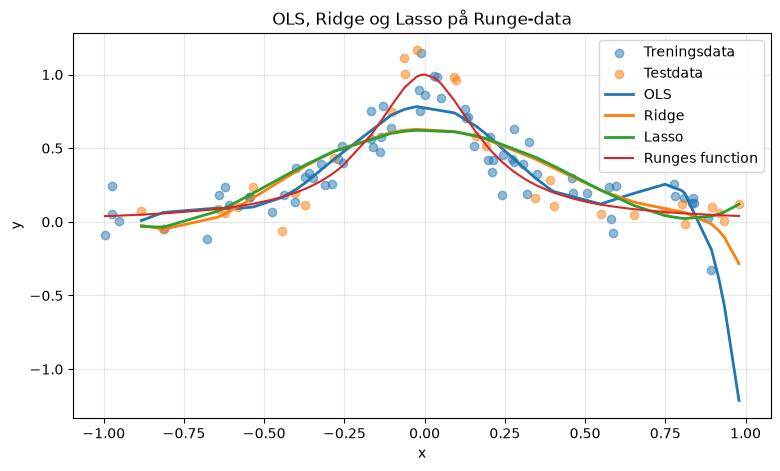

In [62]:
sort_idx = np.argsort(np.asarray(x_test).ravel())
x_test_sorted = np.asarray(x_test).ravel()[sort_idx]
y_test_sorted = np.asarray(y_test).ravel()[sort_idx]

plt.figure(figsize=(9, 5))

plt.scatter(x_train,y_train,alpha=0.5,label="Treningsdata")

plt.scatter(x_test,y_test,alpha=0.5,label="Testdata")

for model_name, result in results_models.items():
    y_pred_sorted = (X_test_sc @ result["theta"])[sort_idx]
    plt.plot(x_test_sorted,y_pred_sorted,linewidth=2,label=model_name)
plt.plot(x,runge(x), label = "Runges function")
plt.xlabel("x")
plt.ylabel("y")
plt.title("OLS, Ridge og Lasso på Runge-data")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

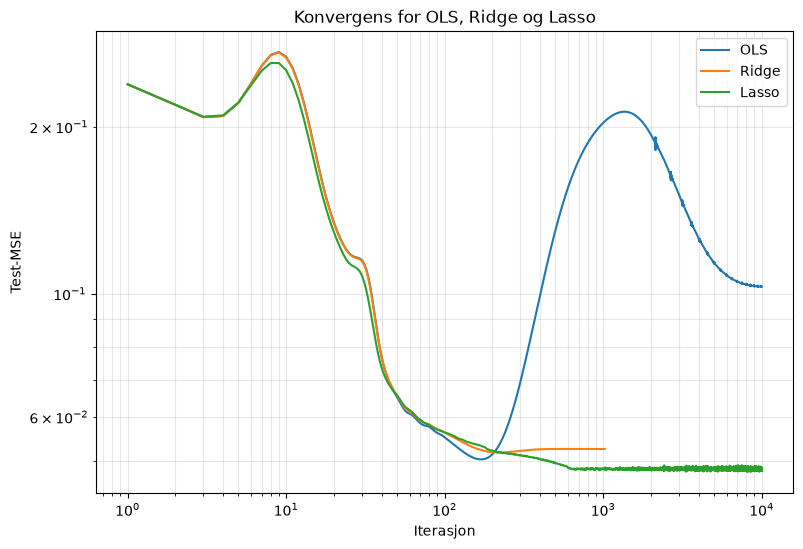

In [63]:
plt.figure(figsize=(9, 6))

for model_name, result in results_models.items():

    theta_path = np.asarray(result["theta_path"])
    test_mse_history = []

    for theta in theta_path:
        y_pred_test = X_test_sc @ theta
        mse = np.mean((y_test - y_pred_test)**2)
        test_mse_history.append(mse)

    iterations = np.arange(1, len(theta_path) + 1)
    plt.loglog(iterations,test_mse_history,label=model_name)

plt.xlabel("Iterasjon")
plt.ylabel("Test-MSE")
plt.title("Konvergens for OLS, Ridge og Lasso")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.show()

H Stochastic gradient descent
-

In [64]:
runs = (("momentum", None),("adagrad", 0.001),("adagrad", 0.01),("adagrad", 0.1),("rmsprop", 0.001),("rmsprop", 0.01),("rmsprop", 0.1),("adam", 0.001), ("adam", 0.01), ("adam", 0.1))

In [12]:
rng = np.random.default_rng(2026)
def make_batches(n, batch_size, rng):
    """Shuffle the indices and split them into minibatches."""
    idx = rng.permutation(n)
    return [idx[i:i + batch_size] for i in range(0, n, batch_size)]

def step_length(t, t0, t1):
    """The schedule of Eq. (4.40)."""
    return t0/(t + t1)

def sgd(X, y, method="plain", n_epochs=50, batch_size=5, gamma=0.1, schedule=None, lam=0.0, seed=2026, **kw):
    """Minibatch SGD, Eq. (4.34), with any optimiser. schedule=(t0, t1) replaces gamma by Eq. (4.40).
    Returns the iterate after every epoch."""
    rng = np.random.default_rng(seed)
    n, p = X.shape
    theta, state, t = np.zeros(p), {}, 0
    history = [theta.copy()]
    for epoch in range(n_epochs):
        for batch in make_batches(n, batch_size, rng):
            t += 1
            g = gradient(theta, X[batch], y[batch], lam)                                   # the gradient of the cost on this minibatch
            gamma_t = gamma if schedule is None else step_length(t-1, *schedule)                             # constant, or the schedule
            theta, state = optimiser_step(method, theta, g, state, t, gamma_t, **kw)
        history.append(theta.copy())
    return np.array(history)


X, y = Xtr_sc, y_train
n = len(y)
theta_cf = closed_form(X, y)
theta = np.zeros(X.shape[1])
g_full = gradient(theta, X, y)
print("full gradient:", g_full)


full gradient: [-0.72613023 -0.0137018   0.41619973 -0.01721887  0.33118812 -0.03542478
  0.28535847 -0.05546648  0.25551654 -0.07371108  0.23365979 -0.08917786
  0.21676724 -0.10181065  0.20342778 -0.1119028 ]


In [66]:
import pandas as pd
rows = []

for M in (1, 5, 25, 70):
    gs = np.array([gradient(theta, X[b], y[b])for _ in range(40)for b in make_batches(n, M, rng)])
    spread = np.std(gs, axis=0).mean()
    rows.append({"Batch size": M,"Mean gradient": np.array2string(gs.mean(axis=0), precision=3, suppress_small=True),"Gradient spread": spread,"Spread × √M": spread * np.sqrt(M),})

gradient_table = pd.DataFrame(rows)
display(gradient_table.style.format({"Gradient spread": "{:.3f}","Spread × √M": "{:.3f}",}).hide(axis="index"))
print("Full gradient:", np.round(g_full, 3))
print("Distance to full gradient", np.linalg.norm(gs.mean(axis=0) - g_full))

Batch size,Mean gradient,Gradient spread,Spread × √M
1,[-0.726 -0.014 0.416 -0.017 0.331 -0.035 0.285 -0.055 0.256 -0.074 0.234 -0.089],0.402,0.402
5,[-0.726 -0.014 0.416 -0.017 0.331 -0.035 0.285 -0.055 0.256 -0.074 0.234 -0.089],0.179,0.400
25,[-0.725 -0.014 0.415 -0.017 0.33 -0.035 0.285 -0.055 0.255 -0.074 0.233 -0.089],0.072,0.361
70,[-0.726 -0.014 0.416 -0.017 0.331 -0.035 0.285 -0.055 0.256 -0.074 0.234 -0.089],0.000,0.000


Full gradient: [-0.726 -0.014  0.416 -0.017  0.331 -0.035  0.285 -0.055  0.256 -0.074
  0.234 -0.089]
Distance to full gradient 5.570623587668902e-16


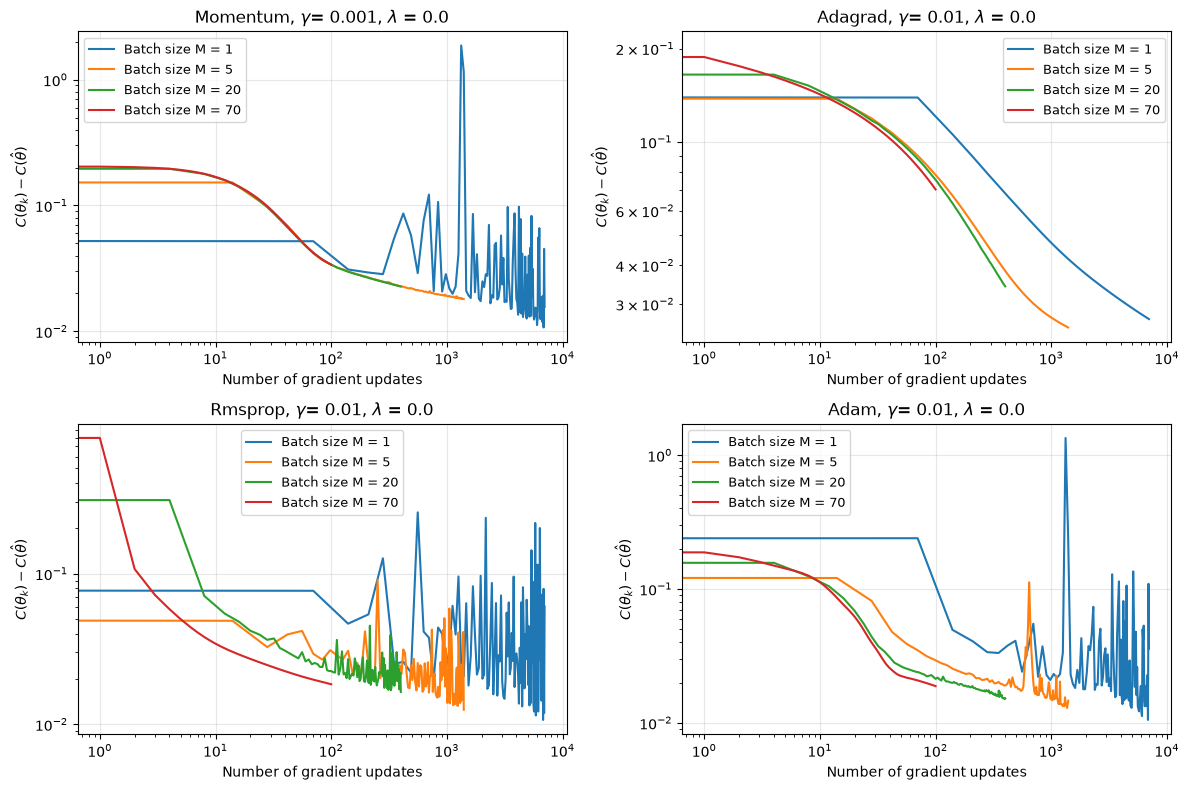

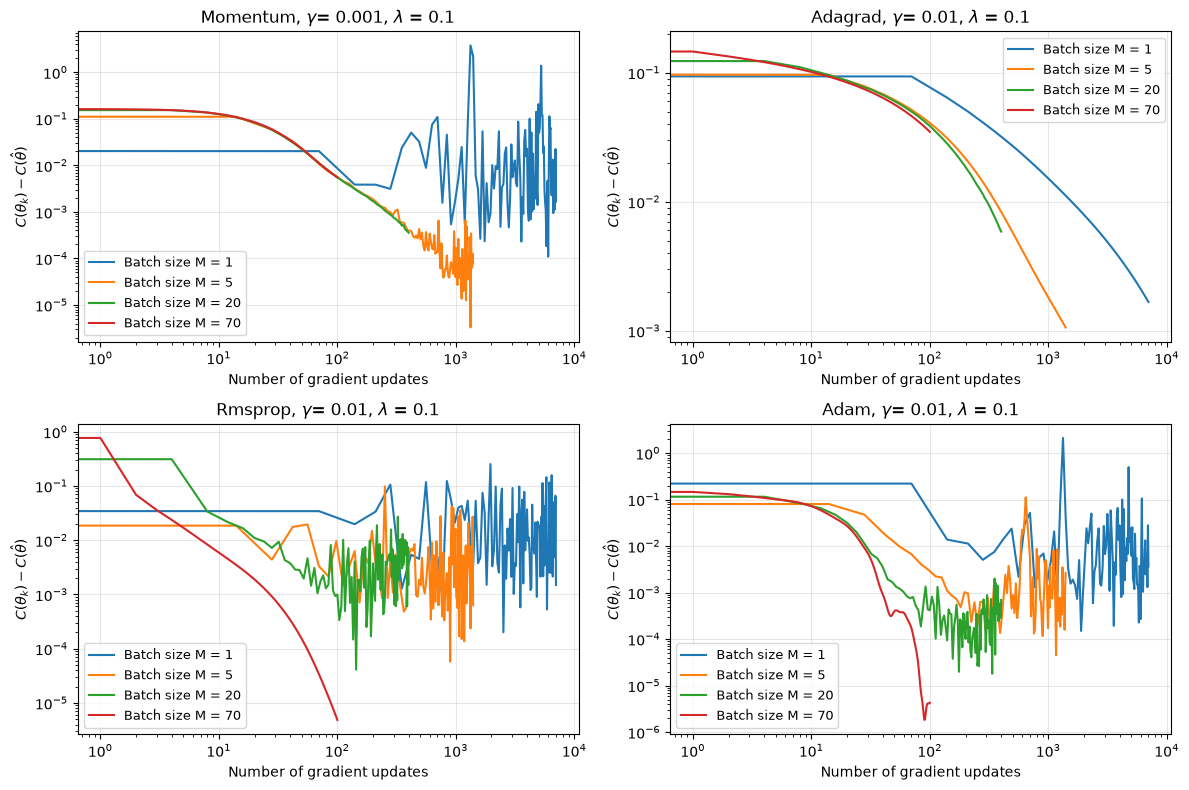

In [67]:
rng = np.random.default_rng(2026)
X, y = Xtr_sc, y_train

n_epochs = 100
batch_sizes = [1, 5, 20, len(y)]
for lam in (0.0, 0.1):
    theta_cf = closed_form(X, y, lam)
    optimal_cost = cost(theta_cf, X, y, lam)

    # Bruk steglengder du har funnet stabile for hver metode.
    gammas = {"momentum": 0.001,"adagrad": 0.01,"rmsprop": 0.01,"adam": 0.01,}

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))

    for ax, (method, gamma) in zip(axes.flat, gammas.items()):
        for M in batch_sizes:
            hist = sgd(X, y,method=method,n_epochs=n_epochs,batch_size=M,gamma=gamma,lam=lam,seed=2026,)

            excess_cost = np.array([cost(theta, X, y, lam) - optimal_cost for theta in hist])

            updates = np.arange(len(hist)) * int(np.ceil(len(y) / M))
            ax.loglog(updates, excess_cost, label=f"Batch size M = {M}")

        ax.set_title(f"{method.capitalize()}, $\gamma$= {gamma}, $\lambda$ = {lam}")
    
        ax.set_xlabel("Number of gradient updates")
        ax.set_ylabel(r"$C(\theta_k)-C(\hat{\theta})$")
        ax.grid(alpha=0.3)
        ax.legend(fontsize = 9)

    plt.tight_layout()
    plt.show()

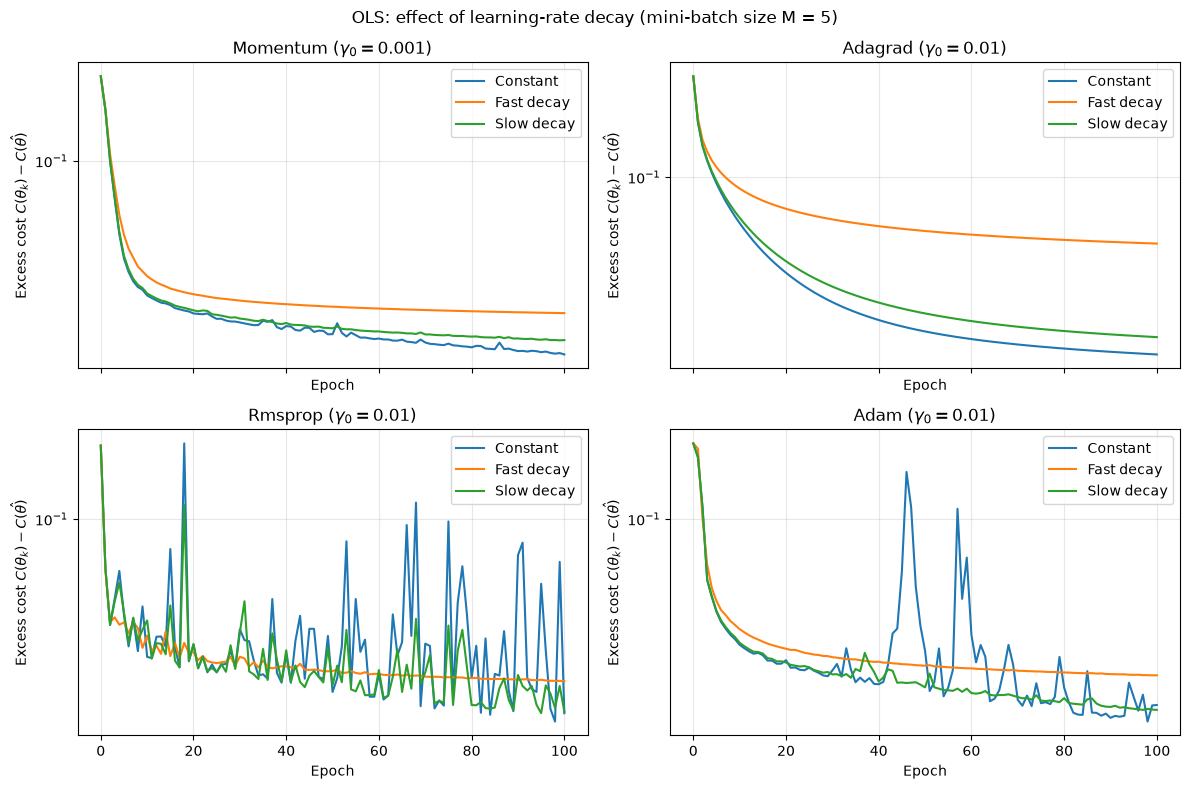

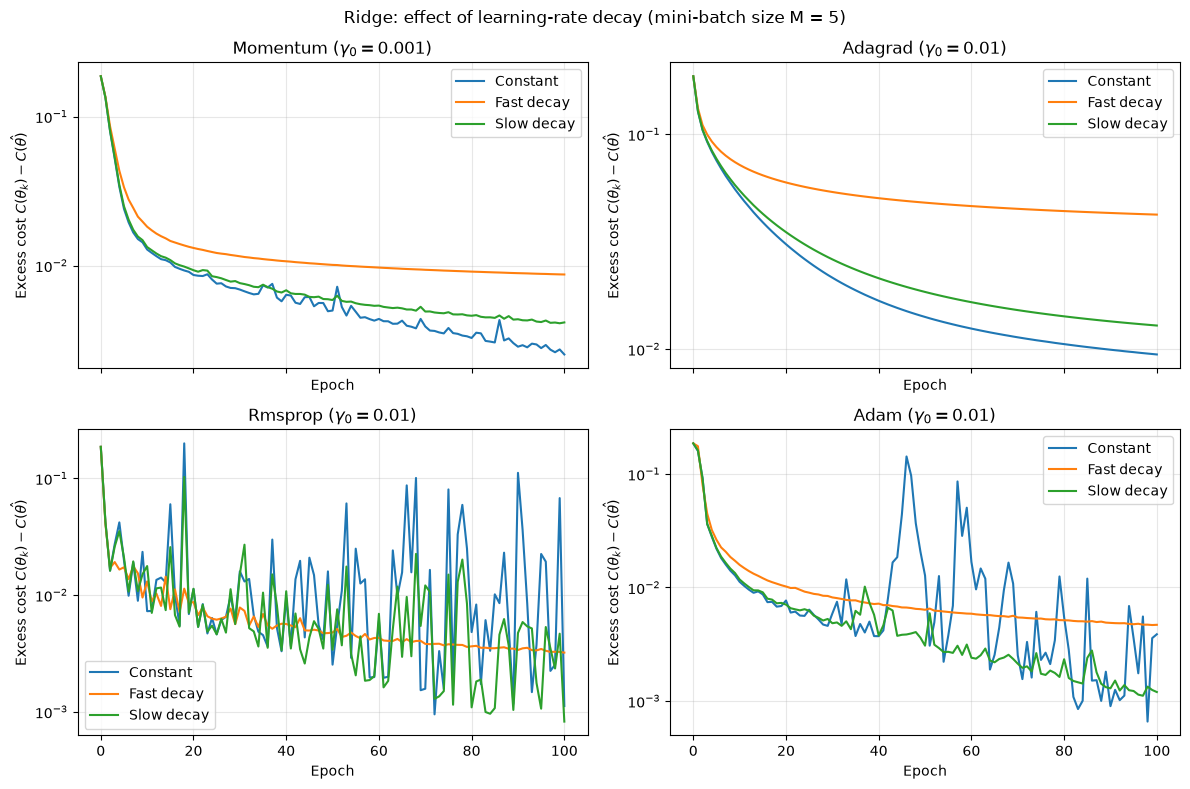

In [48]:
rng = np.random.default_rng(2026)
M = 5
n_epochs = 100


for lam, model in [(0.0, "OLS"), (0.01, "Ridge")]:
    theta_cf = closed_form(X, y, lam=lam)
    best_cost = cost(theta_cf, X, y, lam=lam)

    fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)

    for ax, (method, gamma) in zip(axes.flat, gammas.items()):
        settings = {"Constant": None,"Fast decay": (gamma * 100, 100),"Slow decay": (gamma * 1000, 1000),}

        for label, schedule in settings.items():
            hist = sgd(X, y,method=method,n_epochs=n_epochs,batch_size=M,gamma=gamma,schedule=schedule,lam=lam,seed=2026,)

            excess = np.array([cost(theta, X, y, lam=lam) - best_cost for theta in hist])

            ax.plot(np.arange(len(hist)), excess, label=label)

        ax.set_title(rf"{method.capitalize()} ($\gamma_0={gamma:g}$)")
        ax.set_xlabel("Epoch")
        ax.set_ylabel(r"Excess cost $C(\theta_k)-C(\hat{\theta)}$")
        ax.set_yscale("symlog", linthresh=1e-10)
        ax.grid(alpha=0.3)
        ax.legend()

    fig.suptitle(f"{model}: effect of learning-rate decay "f"(mini-batch size M = {M})")
    fig.tight_layout()
    plt.show()

In [49]:
import time


X, y = Xtr_sc, y_train
n_epochs = 100

gammas = {"momentum": 0.001,"adagrad": 0.01,"rmsprop": 0.01,"adam": 0.01,}

rows = []

for lam, model in [(0.0, "OLS"), (0.01, "Ridge")]:
    theta_cf = closed_form(X, y, lam=lam)
    best_cost = cost(theta_cf, X, y, lam=lam)

    for method, gamma in gammas.items():
        for M in [5, len(y)]:
            start = time.perf_counter()

            hist = sgd(X, y,method=method,batch_size=M,n_epochs=n_epochs,gamma=gamma,lam=lam,schedule=None,seed=2026,)

            elapsed = time.perf_counter() - start

            final_cost = cost(hist[-1], X, y, lam=lam)
            updates = n_epochs * int(np.ceil(len(y) / M))

            rows.append({"Model": model,"Method": method.capitalize(), "Batch size": M, "Updates": updates, "Final excess cost": final_cost - best_cost, "Time (s)": elapsed,})

results = pd.DataFrame(rows)

display(results.style.format({"Final excess cost": "{:.3e}","Time (s)": "{:.3f}", }))

,Model,Method,Batch size,Updates,Final excess cost,Time (s)
0,OLS,Momentum,5,1400,1.897e-02,0.016
1,OLS,Momentum,70,100,3.537e-02,0.002
2,OLS,Adagrad,5,1400,2.786e-02,0.030
3,OLS,Adagrad,70,100,7.197e-02,0.002
4,OLS,Rmsprop,5,1400,1.464e-02,0.021
5,OLS,Rmsprop,70,100,2.177e-02,0.002
6,OLS,Adam,5,1400,1.670e-02,0.023
7,OLS,Adam,70,100,1.931e-02,0.002
8,Ridge,Momentum,5,1400,2.529e-03,0.014
9,Ridge,Momentum,70,100,1.649e-02,0.002


I
-

In [29]:
degrees = np.arange(1, 16)
lambdas = np.logspace(-5, 7, 100)

rng = np.random.default_rng(2026)
sigma = 0.1
n = 100
x = np.sort(rng.uniform(-1,1,n))
y = runge(x) + rng.normal(0, sigma, size = n)    
x = np.asarray(x).reshape(-1, 1)
y = np.asarray(y).ravel()


kf = KFold(n_splits=5, shuffle=True, random_state=2026)
# Rad = polynomgrad, kolonne = lambda
ols_mse = np.zeros(len(degrees))
ridge_mse = np.zeros((len(degrees), len(lambdas)))
lasso_mse = np.zeros((len(degrees), len(lambdas)))

for i, degree in enumerate(degrees):
    poly = PolynomialFeatures(degree=degree, include_bias=False)

    ols_pipe = make_pipeline(poly, LinearRegression())
    ols_mse[i] = -cross_val_score(ols_pipe, x, y, cv=kf,scoring="neg_mean_squared_error").mean()

    for j, lam in enumerate(lambdas):
        ridge_pipe = make_pipeline(PolynomialFeatures(degree=degree, include_bias=False),StandardScaler(),Ridge(alpha=lam))
        ridge_mse[i, j] = -cross_val_score(ridge_pipe, x, y, cv=kf,scoring="neg_mean_squared_error").mean()

        lasso_pipe = make_pipeline(PolynomialFeatures(degree=degree, include_bias=False),StandardScaler(),Lasso(alpha=lam, max_iter=100000, tol=1e-5))
        lasso_mse[i, j] = -cross_val_score(lasso_pipe, x, y, cv=kf,scoring="neg_mean_squared_error").mean()

ols_i = np.argmin(ols_mse)
ridge_i, ridge_j = np.unravel_index(np.argmin(ridge_mse), ridge_mse.shape)
lasso_i, lasso_j = np.unravel_index(np.argmin(lasso_mse), lasso_mse.shape)



C:\Users\torae\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.141486e-01, tolerance: 7.508e-05
  model = cd_fast.enet_coordinate_descent(
C:\Users\torae\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.980161e-02, tolerance: 8.727e-05
  model = cd_fast.enet_coordinate_descent(
C:\Users\torae\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCach

In [28]:
ridge_best_j = np.argmin(ridge_mse, axis=1)
lasso_best_j = np.argmin(lasso_mse, axis=1)

rows = []

for i, degree in enumerate(degrees):
    rows.append({
        "Grad": degree,
        "OLS CV-MSE": ols_mse[i],
        "Ridge lambda": lambdas[ridge_best_j[i]],
        "Ridge CV-MSE": ridge_mse[i, ridge_best_j[i]],
        "Lasso lambda": lambdas[lasso_best_j[i]],
        "Lasso CV-MSE": lasso_mse[i, lasso_best_j[i]]
    })

degree_table = pd.DataFrame(rows)

display(
    degree_table.style.format({
        "OLS CV-MSE": "{:.5f}",
        "Ridge lambda": "{:.5g}",
        "Ridge CV-MSE": "{:.5f}",
        "Lasso lambda": "{:.5g}",
        "Lasso CV-MSE": "{:.5f}"
    }).hide(axis="index")
)

Grad,OLS CV-MSE,Ridge lambda,Ridge CV-MSE,Lasso lambda,Lasso CV-MSE
1,0.10669,1e+07,0.10607,0.024771,0.10607
2,0.05413,2.848,0.05406,0.010723,0.05383
3,0.05744,8.6975,0.05561,0.018738,0.05413
4,0.03427,0.1,0.03423,0.0035112,0.03320
5,0.03504,0.30539,0.03452,0.0035112,0.03331
6,0.02729,0.024771,0.02681,0.00037649,0.02674
7,0.03116,0.043288,0.02763,0.0004977,0.02689
8,0.02253,0.0004977,0.02240,9.326e-05,0.02190
9,0.02376,0.00065793,0.02315,5.3367e-05,0.02245
10,0.02400,0.00012328,0.02224,0.00016298,0.02274
